In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from nilearn import datasets
import scipy
from pathlib import Path
import h5py
import re

_working_path = Path.cwd().resolve()
PROJECT_ROOT = next((
    candidate for candidate in (_working_path, *_working_path.parents)
    if (candidate / 'pyproject.toml').is_file()
    and (candidate / 'data/manual-data').is_dir()
), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f'Could not locate the Neuromatch-Algonauts2026 root from {_working_path}'
    )


## Define paths

In [2]:
feature_path = PROJECT_ROOT / 'data/manual-data'
fmri_path = PROJECT_ROOT / 'data/algonauts_2025.competitors/fmri'

## Variables

In [3]:
# Select the episode and season of interest
SEASON = 1
EPISODE = 1

# Define the subject of interest list
SUB_LIST = [f'sub-{sub_idx:02d}' for sub_idx in range(1, 6) if sub_idx != 4]
print('These are the subjects of interest :',SUB_LIST)

These are the subjects of interest : ['sub-01', 'sub-02', 'sub-03', 'sub-05']


## Get Parcel labels

In [4]:
# Variable setup
atlas = datasets.fetch_atlas_schaefer_2018(n_rois=1000, yeo_networks=7)  

labels = atlas['labels'][1:]                       # drop 'Background' -> 1000
parcel_networks = np.array([l.split('_')[2] for l in labels])

nets = np.unique(parcel_networks)

[fetch_atlas_schaefer_2018] Dataset directory found: /home/ducvu/nilearn_data/schaefer_2018

### Load emotion files

In [5]:
# Find all matching files
files = sorted(feature_path.glob(f'friends_s{SEASON:02d}e{EPISODE:02d}*_my_emotion.tsv'))

# Read and concatenate them
emo_file = pd.concat(
    [pd.read_csv(f, sep='\t') for f in files],
    ignore_index=True
)

# Extract the columns
emo_file_val = emo_file['valence']
emo_file_ar = emo_file['arousal']

# Show unique arousal values
print(emo_file_ar.unique())

[ 1.  0. nan]


### Load fMRI data

In [6]:
episode_pattern = re.compile(
    rf"ses-\d+_task-s{SEASON:02d}e{EPISODE:02d}([a-z]+)$"
)

fmri_by_subject = {}

for sub in SUB_LIST:
    sub_fmri_path = fmri_path / sub / 'func'
    sub_fmri_data_file = sub_fmri_path / f"{sub}_task-friends_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-s123456_bold.h5"
    with h5py.File(sub_fmri_data_file, "r") as f:

        matching_keys = [
            key for key in f.keys()
            if episode_pattern.fullmatch(key)
        ]
        print(matching_keys)

        # Sort episode parts: a, b, c, ...
        matching_keys = sorted(
            matching_keys,
            key=lambda key: episode_pattern.fullmatch(key).group(1)
        )

        if not matching_keys:
            print(
                f"No data found for {sub}, "
                f"season {SEASON}, episode {EPISODE}"
            )
            continue

        episode_parts = [f[key][:] for key in matching_keys]

        # Concatenate time points; retain the 1000 parcels
        episode_fmri = np.concatenate(episode_parts, axis=0)

    fmri_by_subject[sub] = episode_fmri

    print(f"\n{sub}")
    print("Parts:", matching_keys)
    print("Concatenated shape:", episode_fmri.shape)


    

['ses-003_task-s01e01a', 'ses-003_task-s01e01b']

sub-01
Parts: ['ses-003_task-s01e01a', 'ses-003_task-s01e01b']
Concatenated shape: (1184, 1000)
['ses-003_task-s01e01a', 'ses-003_task-s01e01b']

sub-02
Parts: ['ses-003_task-s01e01a', 'ses-003_task-s01e01b']
Concatenated shape: (1184, 1000)
['ses-003_task-s01e01a', 'ses-003_task-s01e01b']

sub-03
Parts: ['ses-003_task-s01e01a', 'ses-003_task-s01e01b']
Concatenated shape: (1184, 1000)
['ses-002_task-s01e01a', 'ses-002_task-s01e01b']

sub-05
Parts: ['ses-002_task-s01e01a', 'ses-002_task-s01e01b']
Concatenated shape: (1184, 1000)


## Plot each subject fMRI timecourse for the episode

In [7]:
def plot_subject_timecourses(
    fmri_by_subject,
    subjects=None,
    tr=None,
    standardize=False,
    max_timepoints=None,
    figsize=(14, 5),
):
    """
    Plot parcel time courses for each subject as a heatmap.

    Parameters
    ----------https://zoom.us/j/5956657375?pwd=Z1RJczZtNm5KU2JpM1FoT2QvMnREQT09
    fmri_by_subject : dict
        Dictionary mapping subject IDs to arrays shaped
        (n_timepoints, n_parcels).

    subjects : list or None
        Subjects to plot. If None, plot every subject.

    tr : float or None
        Repetition time in seconds. If None, the x-axis shows TR indices.

    standardize : bool
        If True, z-score each parcel across time.

    max_timepoints : int or None
        Downsample the time axis to approximately this many points
        for faster plotting.

    figsize : tuple
        Figure size for each subject.
    """
    if subjects is None:
        subjects = list(fmri_by_subject.keys())

    for subject in subjects:
        data = np.asarray(fmri_by_subject[subject])

        if data.ndim != 2:
            raise ValueError(
                f"{subject}: expected shape (time, parcels), got {data.shape}"
            )

        # Standardize each parcel independently
        if standardize:
            mean = np.nanmean(data, axis=0, keepdims=True)
            std = np.nanstd(data, axis=0, keepdims=True)
            std[std == 0] = 1
            data = (data - mean) / std

        # Downsample only for visualization
        step = 1
        if max_timepoints is not None and data.shape[0] > max_timepoints:
            step = int(np.ceil(data.shape[0] / max_timepoints))
            data = data[::step]

        if tr is None:
            x_max = data.shape[0] * step
            x_label = "Time point (TR)"
        else:
            x_max = data.shape[0] * step * tr
            x_label = "Time (seconds)"

        fig, ax = plt.subplots(figsize=figsize)

        image = ax.imshow(
            data.T,
            aspect="auto",
            origin="lower",
            interpolation="nearest",
            extent=[0, x_max, 0, data.shape[1]],
        )

        ax.set_title(
            f"{subject} — parcel time courses "
            f"({data.shape[1]} parcels)"
        )
        ax.set_xlabel(x_label)
        ax.set_ylabel("Parcel index")

        fig.colorbar(image, ax=ax, label="BOLD signal")
        fig.tight_layout()
        plt.show()

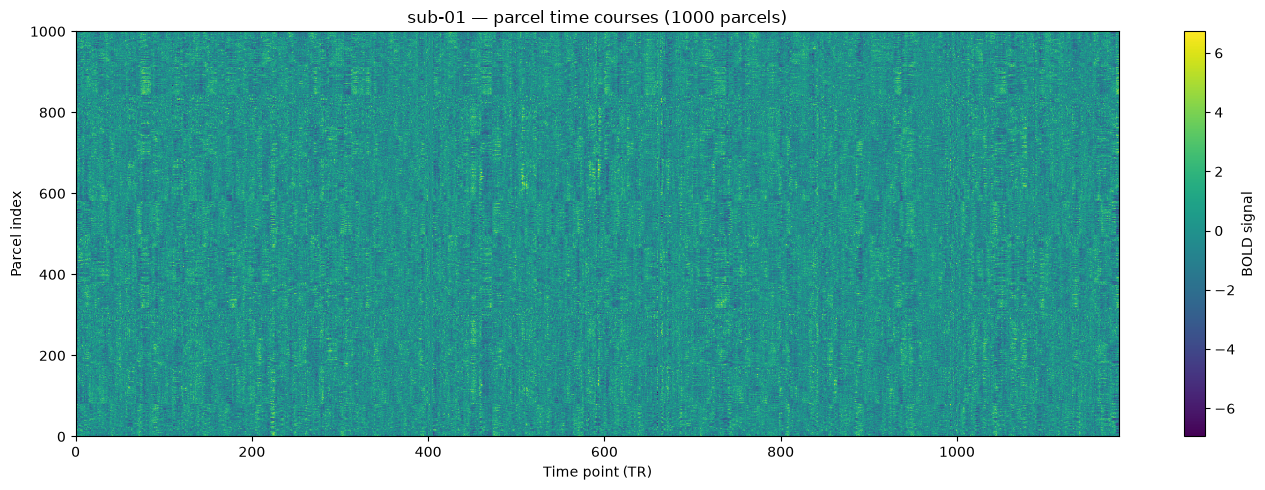

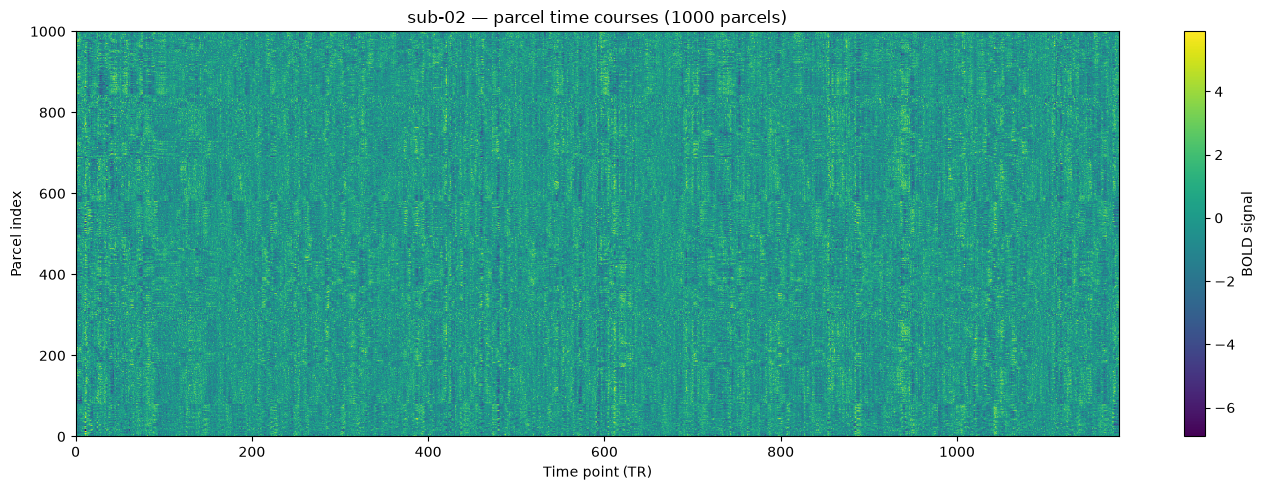

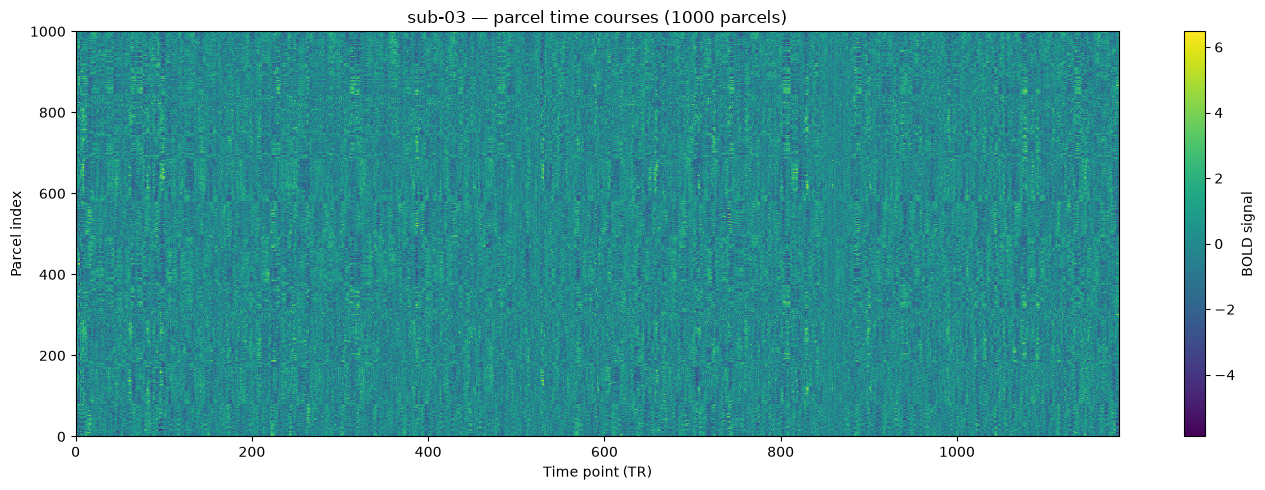

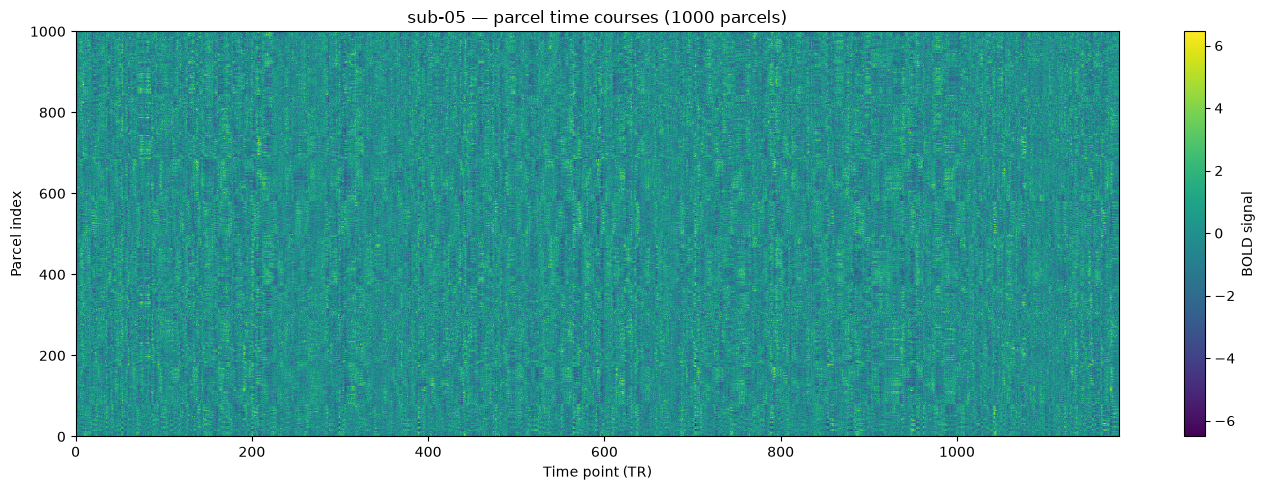

In [8]:
plot_subject_timecourses(
    fmri_by_subject,
    standardize=True,
    max_timepoints=2000,
)

## Shared concatenated HMM


In [ ]:
import joblib
import warnings

from joblib import Parallel, delayed, parallel_config
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler

from preprocessing.brainstates.config import NETWORKS, SUBJECTS
from preprocessing.brainstates.data import (
    SegmentKey,
    common_segments,
    discover_fmri_segments,
)
from preprocessing.brainstates.networks import network_indices


# Data and output locations
FMRI_ROOT = PROJECT_ROOT / 'data/algonauts_2025.competitors/fmri'
CACHE_ROOT = PROJECT_ROOT / 'data/cache'
RESULT_ROOT = PROJECT_ROOT / 'outputs/hmm_shared_s01e01'
FIGURE_ROOT = RESULT_ROOT / 'figures'
RESULT_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

# Config
K_VALUES = tuple(range(4, 18))
N_RESTARTS = 5
N_JOBS = 20
HMM_N_ITER = 200
HMM_TOL = 1e-2
RANDOM_SEED = 2000
TARGET_SEGMENTS = (SegmentKey(1, 1, 'a'), SegmentKey(1, 1, 'b'))


### Build shared network sequences


In [10]:
def load_network_sequences(h5_path, discovered, segments):
    """Load independent episode sequences as seven network means."""
    sequences = []
    segment_ids = []

    with h5py.File(h5_path, 'r') as handle:
        for segment in segments:
            key = discovered.get(segment)
            if key is None:
                raise ValueError(f'Missing segment: {segment.task}')

            parcels = handle[key][:]
            values = np.column_stack([
                parcels[:, PARCEL_INDICES[network]].mean(axis=1)
                for network in NETWORKS
            ])
            if not np.isfinite(values).all():
                raise ValueError(f'Non-finite values: {segment.task}')

            sequences.append(values)
            segment_ids.append(segment.task)

    return sequences, segment_ids


def build_group_data(segments, scalers=None):
    """Standardize within subject, then concatenate independent sequences."""
    fit_scalers = scalers is None
    scalers = {} if fit_scalers else scalers
    transformed_sequences = []
    lengths = []
    keys = []

    for subject in SUBJECTS:
        sequences, segment_ids = load_network_sequences(
            H5_PATHS[subject], DISCOVERED_BY_SUBJECT[subject], segments
        )
        if fit_scalers:
            scalers[subject] = StandardScaler().fit(
                np.concatenate(sequences, axis=0)
            )

        for sequence, segment_id in zip(sequences, segment_ids):
            transformed = scalers[subject].transform(sequence)
            transformed_sequences.append(transformed)
            lengths.append(len(transformed))
            keys.append((subject, segment_id))

    values = np.concatenate(transformed_sequences, axis=0)
    if sum(lengths) != len(values):
        raise ValueError('Sequence lengths do not match concatenated data')
    return values, lengths, keys, scalers


### Small HMM helpers



In [11]:
def fit_hmm_restart(k, restart, values, lengths):
    """Fit one deterministic restart for one state count."""
    model = GaussianHMM(
        n_components=k,
        covariance_type='full',
        n_iter=HMM_N_ITER,
        tol=HMM_TOL,
        random_state=RANDOM_SEED + restart,
    )
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', RuntimeWarning)
            model.fit(values, lengths)
        train_ll = model.score(values, lengths)
    except (ValueError, FloatingPointError, np.linalg.LinAlgError):
        return k, restart, None, -np.inf

    if not np.isfinite(train_ll):
        return k, restart, None, -np.inf
    return k, restart, model, float(train_ll)


def fit_best_hmms(k_values, values, lengths):
    """Fit restarts in parallel and return the best model for each K."""
    k_values = tuple(k_values)
    n_jobs = min(N_JOBS, len(k_values) * N_RESTARTS)
    tasks = (
        delayed(fit_hmm_restart)(k, restart, values, lengths)
        for k in k_values
        for restart in range(N_RESTARTS)
    )
    with parallel_config(
        backend='loky', n_jobs=n_jobs, inner_max_num_threads=1
    ):
        fits = Parallel(verbose=10)(tasks)

    best = {}
    for k, _restart, model, train_ll in fits:
        if model is not None and (
            k not in best or train_ll > best[k][1]
        ):
            best[k] = (model, train_ll)

    failed = [k for k in k_values if k not in best]
    if failed:
        raise RuntimeError(f'All HMM restarts failed for K={failed}')
    return best


def score_sequences(model, values, lengths):
    """Return log-likelihood per TR for every independent sequence."""
    scores = []
    start = 0
    for length in lengths:
        stop = start + length
        scores.append(model.score(values[start:stop]) / length)
        start = stop
    return np.asarray(scores)


def summarize_state_emotion(subject, gamma, states, labels):
    """Summarize soft posterior and hard occupancy for one subject."""
    rows = []
    for label_name in ('valence', 'arousal'):
        label_values = labels[label_name].to_numpy()
        for label_value in sorted(labels[label_name].dropna().unique()):
            mask = label_values == label_value
            for state in range(gamma.shape[1]):
                rows.append({
                    'subject': subject,
                    'state': state,
                    'label': label_name,
                    'label_value': label_value,
                    'n_tr': int(mask.sum()),
                    'mean_posterior': float(gamma[mask, state].mean()),
                    'viterbi_occupancy': float((states[mask] == state).mean()),
                })
    return pd.DataFrame(rows)


### Discover common episodes and define held-out splits

In [12]:
H5_PATHS = {
    subject: (
        FMRI_ROOT / subject / 'func'
        / f'{subject}_task-friends_space-MNI152NLin2009cAsym_'
          'atlas-Schaefer18_parcel-1000Par7Net_desc-s123456_bold.h5'
    )
    for subject in SUBJECTS
}
missing_files = [str(path) for path in H5_PATHS.values() if not path.is_file()]
if missing_files:
    raise FileNotFoundError(f'Missing fMRI files: {missing_files}')

DISCOVERED_BY_SUBJECT = {
    subject: discover_fmri_segments(path)
    for subject, path in H5_PATHS.items()
}
COMMON_SEGMENTS = common_segments(DISCOVERED_BY_SUBJECT)
missing_targets = [
    segment.task for segment in TARGET_SEGMENTS
    if segment not in COMMON_SEGMENTS
]
if missing_targets:
    raise ValueError(f'Missing target segments: {missing_targets}')

train_segments = tuple(
    segment for segment in COMMON_SEGMENTS
    if segment.season <= 4 and segment not in TARGET_SEGMENTS
)
validation_segments = tuple(
    segment for segment in COMMON_SEGMENTS if segment.season == 5
)
final_train_segments = tuple(
    segment for segment in COMMON_SEGMENTS
    if segment.season <= 5 and segment not in TARGET_SEGMENTS
)

PARCEL_INDICES = network_indices(CACHE_ROOT)

print('Subjects:', SUBJECTS)
print('Networks:', NETWORKS)
print('Training episodes:', len(train_segments))
print('Validation episodes:', len(validation_segments))
print('Final-training episodes:', len(final_train_segments))
print('Held-out target:', [segment.task for segment in TARGET_SEGMENTS])


[fetch_atlas_schaefer_2018] Dataset directory found: 
/home/ducvu/project/Neuromatch-Algonauts2026/data/cache/schaefer_2018

Subjects: ('sub-01', 'sub-02', 'sub-03', 'sub-05')
Networks: ('VIS', 'SMN', 'DAN', 'SAL', 'LIM', 'FPC', 'DN')
Training episodes: 189
Validation episodes: 47
Final-training episodes: 236
Held-out target: ['s01e01a', 's01e01b']


### Prepare candidate training and validation data

In [13]:
train_values, train_lengths, train_keys, train_scalers = build_group_data(
    train_segments
)
validation_values, validation_lengths, validation_keys, _ = build_group_data(
    validation_segments, train_scalers
)

print('Shared training matrix:', train_values.shape)
print('Shared validation matrix:', validation_values.shape)
print('Independent training sequences:', len(train_lengths))
print('Independent validation sequences:', len(validation_lengths))


Shared training matrix: (355916, 7)
Shared validation matrix: (89944, 7)
Independent training sequences: 756
Independent validation sequences: 188


### Select the number of shared states

Training LL, AIC, and BIC are diagnostics. The selected K maximizes held-out
Season 5 likelihood per TR.


In [14]:
candidate_fits = fit_best_hmms(
    K_VALUES, train_values, train_lengths
)
selection_rows = []

for k in K_VALUES:
    candidate_model, train_ll = candidate_fits[k]
    validation_scores = score_sequences(
        candidate_model, validation_values, validation_lengths
    )
    selection_rows.append({
        'k': k,
        'train_ll': train_ll,
        'aic': candidate_model.aic(train_values, train_lengths),
        'bic': candidate_model.bic(train_values, train_lengths),
        'validation_mean': float(validation_scores.mean()),
        'validation_se': float(
            validation_scores.std(ddof=1) / np.sqrt(len(validation_scores))
        ),
        'iterations': candidate_model.monitor_.iter,
        'converged': candidate_model.monitor_.converged,
    })
    print(
        f'K={k:2d} | train LL={train_ll:12.1f} | '
        f'validation LL/TR={validation_scores.mean():.4f}'
    )

selection_table = pd.DataFrame(selection_rows).sort_values('k')
selected_k = int(selection_table.sort_values(
    ['validation_mean', 'k'], ascending=[False, True]
).iloc[0]['k'])

selection_table.to_csv(RESULT_ROOT / 'model_selection.csv', index=False)
print('Selected shared-state count:', selected_k)
selection_table


K= 4 | train LL=  -3127266.8 | validation LL/TR=-8.9996
K= 5 | train LL=  -3100881.3 | validation LL/TR=-8.9225
K= 6 | train LL=  -3080216.8 | validation LL/TR=-8.8400


KeyboardInterrupt: 

### Plot model-selection diagnostics

The right panel is the actual selection criterion. AIC, BIC, and training LL
help diagnose whether additional states only improve in-sample fit.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# In-sample diagnostics
axes[0].plot(selection_table['k'], selection_table['aic'], 'o-', label='AIC')
axes[0].plot(selection_table['k'], selection_table['bic'], 'o-', label='BIC')
axes[0].set(
    title='In-sample diagnostics',
    xlabel='Number of states (K)',
    ylabel='AIC / BIC (lower is better)',
)
ll_axis = axes[0].twinx()
ll_axis.plot(
    selection_table['k'], selection_table['train_ll'],
    'o--', color='tab:orange', label='Training LL'
)
ll_axis.set_ylabel('Training log-likelihood', color='tab:orange')
handles_a, labels_a = axes[0].get_legend_handles_labels()
handles_b, labels_b = ll_axis.get_legend_handles_labels()
axes[0].legend(handles_a + handles_b, labels_a + labels_b, frameon=False)

# Held-out selection criterion
axes[1].errorbar(
    selection_table['k'], selection_table['validation_mean'],
    yerr=selection_table['validation_se'], marker='o', capsize=3,
)
axes[1].axvline(
    selected_k, color='tab:red', linestyle='--',
    label=f'Selected K={selected_k}'
)
axes[1].set(
    title='Held-out Season 5 selection',
    xlabel='Number of states (K)',
    ylabel='Mean log-likelihood per TR (higher is better)',
)
axes[1].legend(frameon=False)

for axis in axes:
    axis.set_xticks(K_VALUES)
    axis.grid(alpha=0.2)

fig.suptitle('Shared concatenated HMM model selection', fontsize=14)
fig.savefig(FIGURE_ROOT / 'model_selection.png', dpi=180)
plt.show()


### Fit the final shared HMM and decode S01E01

The final scalers and HMM use Seasons 1-5 except S01E01. Target posterior
probabilities and Viterbi states are computed only after fitting finishes.


In [ ]:
final_train_values, final_train_lengths, final_train_keys, final_scalers = (
    build_group_data(final_train_segments)
)
target_values, target_lengths, target_keys, _ = build_group_data(
    TARGET_SEGMENTS, final_scalers
)

final_model, final_train_ll = fit_best_hmms(
    (selected_k,), final_train_values, final_train_lengths
)[selected_k]
target_gamma = final_model.predict_proba(target_values, target_lengths)
target_states = final_model.predict(target_values, target_lengths)

model_path = RESULT_ROOT / 'shared_hmm.joblib'
joblib.dump({
    'model': final_model,
    'scalers': final_scalers,
    'subjects': SUBJECTS,
    'networks': NETWORKS,
    'selected_k': selected_k,
    'target_keys': target_keys,
    'target_lengths': target_lengths,
    'final_train_ll': final_train_ll,
}, model_path)

print('Final training matrix:', final_train_values.shape)
print('Held-out target matrix:', target_values.shape)
print('Saved model:', model_path)


### Split shared decoding back into subjects

The model is shared, but every subject keeps an individual state timeline and
posterior matrix for the emotion analysis.


In [ ]:
decoded_by_subject = {
    subject: {'gamma': [], 'states': [], 'part_lengths': [], 'segments': []}
    for subject in SUBJECTS
}

start = 0
for (subject, segment_id), length in zip(target_keys, target_lengths):
    stop = start + length
    decoded_by_subject[subject]['gamma'].append(target_gamma[start:stop])
    decoded_by_subject[subject]['states'].append(target_states[start:stop])
    decoded_by_subject[subject]['part_lengths'].append(length)
    decoded_by_subject[subject]['segments'].append(segment_id)
    start = stop

for subject, decoded in decoded_by_subject.items():
    decoded['gamma'] = np.concatenate(decoded['gamma'], axis=0)
    decoded['states'] = np.concatenate(decoded['states'])
    print(subject, decoded['gamma'].shape, decoded['segments'])


### Relate held-out states to emotion labels

Emotion labels enter for the first time here, after model fitting and S01E01
decoding. Posterior means are the primary soft association measure.


In [ ]:
emotion_labels = emo_file[['valence', 'arousal']].reset_index(drop=True)
summary_frames = []

for subject, decoded in decoded_by_subject.items():
    if len(decoded['gamma']) != len(emotion_labels):
        raise ValueError(
            f'{subject}: {len(decoded["gamma"])} decoded TRs but '
            f'{len(emotion_labels)} emotion rows'
        )
    summary_frames.append(summarize_state_emotion(
        subject,
        decoded['gamma'],
        decoded['states'],
        emotion_labels,
    ))

state_emotion_table = pd.concat(summary_frames, ignore_index=True)
state_emotion_table.to_csv(
    RESULT_ROOT / 'state_emotion_by_subject.csv', index=False
)
state_emotion_table.head()


### Plot the shared state definitions

In [ ]:
state_means = final_model.means_
color_limit = max(float(np.abs(state_means).max()), 1e-6)

fig, ax = plt.subplots(figsize=(9, max(4, selected_k * 0.45)))
image = ax.imshow(
    state_means, aspect='auto', cmap='RdBu_r',
    vmin=-color_limit, vmax=color_limit,
)
ax.set_xticks(range(len(NETWORKS)), NETWORKS)
ax.set_yticks(range(selected_k), [f'State {state}' for state in range(selected_k)])
ax.set_xlabel('Network')
ax.set_ylabel('Shared HMM state')
ax.set_title('Shared state network profiles')
fig.colorbar(image, ax=ax, label='Mean standardized activity')
fig.tight_layout()
fig.savefig(FIGURE_ROOT / 'state_network_profiles.png', dpi=180)
plt.show()


### Plot each subject's held-out S01E01 timeline

In [ ]:
timepoints = np.arange(len(emotion_labels))

for subject, decoded in decoded_by_subject.items():
    gamma = decoded['gamma']
    states = decoded['states']
    boundaries = np.cumsum(decoded['part_lengths'])[:-1]

    fig, axes = plt.subplots(
        4, 1, figsize=(16, 9), sharex=True,
        gridspec_kw={'height_ratios': (2.2, 1, 1, 1)},
        constrained_layout=True,
    )
    posterior = axes[0].imshow(
        gamma.T, aspect='auto', origin='lower', interpolation='nearest',
        extent=[0, len(gamma), -0.5, selected_k - 0.5], vmin=0, vmax=1,
    )
    axes[0].set_ylabel('State')
    axes[0].set_title(f'{subject}: shared-state posterior probability')
    fig.colorbar(posterior, ax=axes[0], label='Probability')

    axes[1].step(timepoints, states, where='mid', linewidth=0.8)
    axes[1].set_ylabel('Viterbi state')
    axes[1].set_yticks(range(selected_k))
    axes[2].step(
        timepoints, emotion_labels['valence'],
        where='mid', color='tab:purple',
    )
    axes[2].set_ylabel('Valence')
    axes[2].set_yticks([-1, 0, 1])
    axes[3].step(
        timepoints, emotion_labels['arousal'],
        where='mid', color='tab:orange',
    )
    axes[3].set_ylabel('Arousal')
    axes[3].set_yticks([0, 1])
    axes[3].set_xlabel('S01E01 time point (TR)')

    for axis in axes:
        for boundary in boundaries:
            axis.axvline(boundary, color='black', linestyle='--', linewidth=1)

    figure_path = FIGURE_ROOT / f'{subject}_timeline.png'
    fig.savefig(figure_path, dpi=180)
    plt.show()


### Check whether emotion-state associations repeat across subjects

In [ ]:
def posterior_difference(label, high_value, low_value):
    differences = []
    for subject in SUBJECTS:
        group = state_emotion_table.loc[
            state_emotion_table['subject'].eq(subject)
            & state_emotion_table['label'].eq(label)
        ]
        high = group.loc[
            group['label_value'].eq(high_value)
        ].sort_values('state')['mean_posterior'].to_numpy()
        low = group.loc[
            group['label_value'].eq(low_value)
        ].sort_values('state')['mean_posterior'].to_numpy()
        if len(high) != selected_k or len(low) != selected_k:
            raise ValueError(f'{subject}: incomplete {label} summary')
        differences.append(high - low)
    return np.vstack(differences)


arousal_difference = posterior_difference('arousal', 1.0, 0.0)
valence_difference = posterior_difference('valence', 1.0, -1.0)
color_limit = max(
    float(np.abs(arousal_difference).max()),
    float(np.abs(valence_difference).max()),
    1e-6,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
for axis, values, title in (
    (axes[0], arousal_difference, 'High minus low arousal'),
    (axes[1], valence_difference, 'Positive minus negative valence'),
):
    image = axis.imshow(
        values, aspect='auto', cmap='RdBu_r',
        vmin=-color_limit, vmax=color_limit,
    )
    axis.set_xticks(range(selected_k), range(selected_k))
    axis.set_yticks(range(len(SUBJECTS)), SUBJECTS)
    axis.set_xlabel('Shared state')
    axis.set_ylabel('Subject')
    axis.set_title(title)
    for row in range(len(SUBJECTS)):
        for column in range(selected_k):
            axis.text(
                column, row, f'{values[row, column]:.2f}',
                ha='center', va='center', fontsize=7,
            )
    fig.colorbar(image, ax=axis, label='Posterior difference')

fig.suptitle('Consistency of state-emotion relationships across subjects')
fig.savefig(FIGURE_ROOT / 'emotion_state_consistency.png', dpi=180)
plt.show()

print('Results:', RESULT_ROOT)
print('Figures:', FIGURE_ROOT)
